In [1]:
import illustris_python as il
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
from scipy import integrate
import pickle
from scipy.stats import binned_statistic
import random
from NFWdist import *

In [2]:
snapnum = 40
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200", "Group_R_TopHat200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [75]:

mvirs = np.log10(halos["Group_M_TopHat200"]*1e10)
mfofs = np.log10(halos["GroupMass"]*1e10)
rvirs = halos["Group_R_TopHat200"]
sfrs = halos["GroupSFR"]
pos = halos["GroupPos"]
mask = (mvirs > 13) & (mvirs < 13.1)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  


In [4]:
fname = "toy_models/weighted_c4_rvir0.5_n200/ref0/nfw_sat_pos_w2_in_rs.txt"
_,_, x,y,z, weight =  np.loadtxt(fname, unpack=True)

In [86]:
con1 = 4
ngal = 50
r_s = 125

def get_profiles_from_subs(nhalos, bin_edges, istart=0):   
        bin_volumes = (4/3) * np.pi * (bin_edges[1:]**3 - bin_edges[:-1]**3)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        r_values = rnfw(ngal,con=con1)
        weights = np.ones(ngal)
        rvir=500
        r_values *= rvir
        mask = r_values < r_s

        weights[mask] = np.random.normal(loc=2, scale=1)

        
        counts_sfr, _ = np.histogram(r_values, weights=weights, bins=bin_edges)


        counts_dm, _ = np.histogram(r_values,  bins=bin_edges)

                

        mean_sfr, bin_edges, binnumber = binned_statistic(r_values, weights, bins=bin_edges)
    
                
        
        sfr_profile = counts_sfr/bin_volumes
        dm_profile = counts_dm/bin_volumes

        sfr_profile_normed = sfr_profile/ngal
        dm_profile_normed = dm_profile/ngal

        return bin_centers, dm_profile_normed, sfr_profile_normed, sfr_profile, mean_sfr

In [87]:

bin_edges_nonzero = np.logspace(1, 3, 10)
bin_edges = bin_edges_nonzero
nhalos=np.sum(mask)
dm_profile_list = []
sfr_profile_list = []
sfr_profile_list_weighted = []
sfr_mean_list = []

random.seed(0)
np.random.seed(0)

for i in range(nhalos):
    nhalo = 1
    bin_centers, dm_profile_normed, sfr_profile_normed, sfr_profile, mean_sfr = get_profiles_from_subs(nhalo, bin_edges, istart=i)
    dm_profile_list.append(dm_profile_normed)
    sfr_profile_list.append(sfr_profile_normed)
    sfr_profile_list_weighted.append(sfr_profile)
    sfr_mean_list.append(mean_sfr)
# plt.xlim(10,10000)
# plt.loglog()

In [81]:
dm_profile_list[0]

array([6.55572129e-07, 4.23716201e-07, 3.04289628e-08, 7.86686555e-08,
       1.55362607e-08, 5.78150292e-09, 2.16338803e-09, 2.82477468e-10,
       0.00000000e+00])

In [82]:
# sfr_profile_arr = np.array(sfr_profile_list)
# a = np.where(sfr_profile_arr > 0, sfr_profile_arr, np.nan)
# nonzero_mean = np.nanmean(a, axis=0)

In [88]:
mean_dm_dist = np.mean(dm_profile_list, axis=0)
std_dm =  np.std(dm_profile_list, axis=0)

mean_sfr_dist = np.mean(sfr_profile_list, axis=0)
std_sfr =  np.std(sfr_profile_list, axis=0)
sfr75 =  np.percentile(sfr_profile_list, 75, axis=0)
sfr95 =  np.percentile(sfr_profile_list, 95, axis=0)

In [89]:
sfr_mean_arr = np.array(sfr_mean_list)
mean_sfr = np.mean(sfr_mean_arr, axis=0)

In [68]:
mean_sfr

array([       nan, 1.94721333, 1.94721333, 1.94721333, 1.80539476,
       1.        , 1.        , 1.        ,        nan])

In [69]:
# mask = mean_sfr > 1
# mean_sfr[mask] = mean_sfr[mask] * 5

In [70]:
def nfw_profile(r, rho0, rs):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

def rho_s(mvir, r_s, c):
    rhos = (mvir/(4*np.pi*r_s**3))*(np.log(1+c) - c/(1+c))**-1
    return rhos

In [71]:
rvir = 500
print(rvir)
#rvir=1300
c = 4
r_s = rvir/c
print(r_s)
rho0 = rho_s(10**13, r_s, c)
print(rho0)

500
125.0
503357.5127337802


In [72]:
rvir = 500
print(rvir)
#rvir=1300
c2 = 50
r_s2 = rvir/c2
#print(r_s)
rho02 = rho_s(10**13, r_s2, c2)
#print(rho0)

500


4

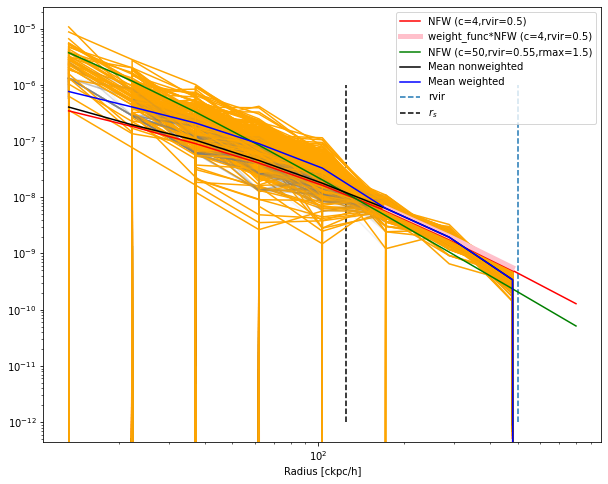

In [90]:
plt.figure(figsize=(10,8))
for i in range(0,nhalos):
    plt.plot(bin_centers, dm_profile_list[i], c="grey", alpha=0.1)
    plt.plot(bin_centers, sfr_profile_list[i], c="orange")
    #plt.plot(bin_centers, sfr_profile_list[i])
    

#r_s = 200
#r_s = 200
#rho0 = 145597


plt.plot(bin_centers, nfw_profile(bin_centers, rho0, r_s)/10**13.05, label="NFW (c=4,rvir=0.5)", c="red")
plt.plot(bin_centers, (mean_sfr)*nfw_profile(bin_centers, rho0, r_s)/10**13, label="weight_func*NFW (c=4,rvir=0.5)", c="pink",linewidth=5)

plt.plot(bin_centers, nfw_profile(bin_centers, rho02, r_s2)/10**13, label=f"NFW (c={c2},rvir=0.55,rmax=1.5)", c="green")
#plt.plot(bin_centers, nfw_profile(bin_centers, rho03, r_s3)/10**mean_mvir, label="NFW (c=8,rvir=0.55)", c="dodgerblue")

plt.plot(bin_centers, mean_dm_dist, c="black", label="Mean nonweighted")
plt.plot(bin_centers, mean_sfr_dist, c="blue", label="Mean weighted")

#plt.plot(bin_centers, nonzero_mean, c="lightblue", label="Mean SFR_nonzero")
#plt.plot(bin_centers, weighted_mean_sfr_dist, c="dodgerblue", label="Weighted Mean SFR")
#plt.plot(bin_centers, sfr75, c="blue", linestyle="dotted", label="75th percentile")
#plt.plot(bin_centers, sfr95, c="blue", linestyle="dashed", label="95th percentile")
ymin = 10**-12
ymax = 10**-6
plt.vlines(500, ymin, ymax, label="rvir", linestyle="dashed")
plt.vlines(r_s, ymin, ymax, label="$r_s$", linestyle="dashed", color="k")
#plt.xlim(100,1000)
#plt.ylim(-15,-5)
plt.loglog()
plt.xlabel("Radius [ckpc/h]")
plt.legend()
